In [1]:
import pandas as pd
import numpy as np
import subprocess
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
from scipy.stats import mannwhitneyu

In [2]:
PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = PROJECT_ROOT / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_DIR  = PROJECT_ROOT / 'analysis_outputs/Task1A'
TASK_OUTPUT = PROJECT_ROOT / "outputs/"

In [68]:
# THE SCRIPT CMD I USED TO RUN MY ANALYSIS

# cmd = [
#     sys.executable, 
#     str(SCRIPTS_DIR / 'compare_spatiotemporal_behavior.py'),
#     '--data-path', str(DATA_PATH),
#     '--meta-path', str(META_PATH),
#     '--signal-col', 'ERKKTR_ratio',
#     '--spatial-radius', '60',
#     '--future-window-frames', '3',
#     '--jump-quantile', '0.9',
#     '--exclude-mutations', 'ErbB2',
#     '--output-dir', str(OUTPUT_DIR)
# ]
# subprocess.run(cmd, capture_output=True)

In [3]:
block_df = pd.read_csv(OUTPUT_DIR / "block_level_summary.csv")
group_df = pd.read_csv(OUTPUT_DIR / "group_level_summary.csv")

In [78]:
wt_samples = block_df[block_df["mutation"] == "WT"]["relative_risk"]
mutants = ["AKT1_E17K", "PIK3CA_E545K", "PIK3CA_H1047R", "PTEN_del"]

results = []
alpha = 0.05
# Bonferonni correction - alpha / number of commparisons, in this case it's 4 
alpha_adj = alpha / len(mutants)

for mut in mutants:
    mut_samples = block_df[block_df["mutation"] == mut]['relative_risk']
    
    # Compare WT and specified mutation sampels
    stat, p_raw = mannwhitneyu(wt_samples, mut_samples, alternative='two-sided')

    sig = p_raw < alpha_adj

    mean_rr = mut_samples.mean()
    std_err = mut_samples.sem()
    
    results.append({
        'mutation': mut,
        'mean_RR': mean_rr,
        'std_error': std_err,
        'p_value_vs_WT': p_raw,
        'significant': sig
    })

In [101]:
results_df = pd.DataFrame(results)
results_df.to_csv(TASK_OUTPUT / "mutations_comparison_table.csv")
results_df

,mutation,mean_RR,std_error,p_value_vs_WT,significant
0,AKT1_E17K,1.581421,0.071932,3.461467e-03,True
1,PIK3CA_E545K,1.707110,0.031885,1.835290e-01,False
2,PIK3CA_H1047R,3.200310,0.130643,3.063664e-09,True
3,PTEN_del,1.556633,0.021624,3.660584e-07,True


In [111]:
wt_mean = wt_samples.mean()

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_145842/395648440.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Mean Relative Risk ($\overline{RR} \pm SE$)')


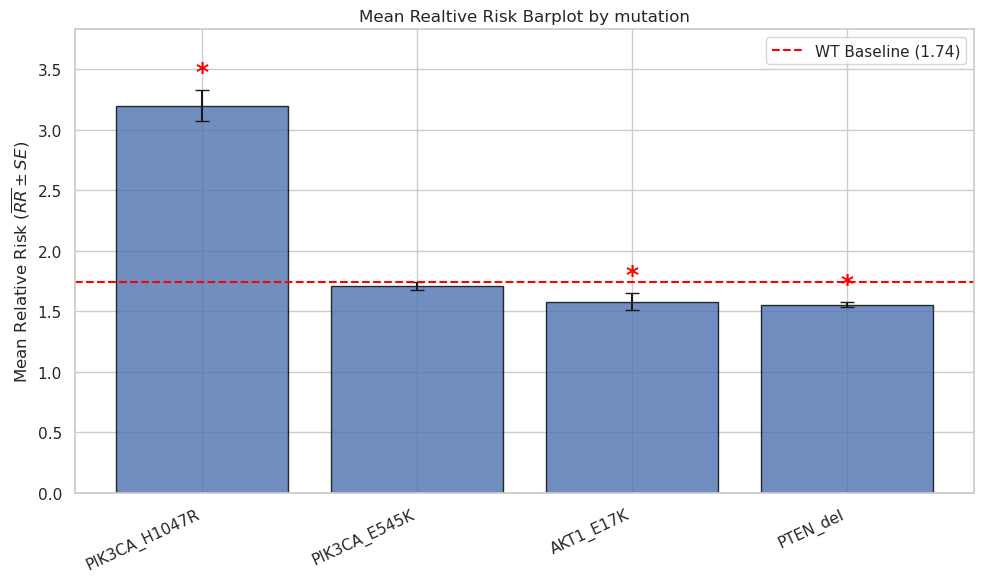

In [122]:
# For a horizontal line 
wt_mean = wt_samples.mean()
df_plot = results_df.sort_values('mean_RR', ascending=False)

plt.figure(figsize=(10, 6))
x_pos = np.arange(len(df_plot))

bars = plt.bar(x_pos, df_plot['mean_RR'], yerr=df_plot['std_error'], 
               capsize=5, edgecolor='black', alpha=0.8)

# Plot * above statistically significant mutations
for i, row in df_plot.iterrows():
    if row['significant']:
        plt.text(np.where(df_plot['mutation'] == row['mutation'])[0][0], 
                 row['mean_RR'] + row['std_error'] + 0.05, '*', 
                 ha='center', va='bottom', fontsize=18, color='red', fontweight='bold')

plt.axhline(wt_mean, color='red', linestyle='--', linewidth=1.5, label=f'WT Baseline ({wt_mean:.2f})')
plt.xticks(x_pos, df_plot['mutation'], rotation=25, ha='right')
plt.ylabel('Mean Relative Risk ($\overline{RR} \pm SE$)')
plt.title('Mean Realtive Risk Barplot by mutation')
plt.ylim(0, max(df_plot['mean_RR'] + df_plot['std_error']) + 0.5)
plt.tight_layout()
plt.legend()
plt.savefig(TASK_OUTPUT / "mutations_barplot.png")
plt.show()

## Interpretacja

Przeprowadzona analiza miała na celu zbadanie wpływu mutacji szlaku PI3K-AKT na koordynację sygnału ERK w komórkach MCF10A. Kluczowym badanym wskaźnikiem było ryzyko względne (RR), określające, o ile skok aktywności sąsiada zwiększa prawdopodobieństwo własnej reakcji w ciągu 15 minut. Dla typu dzikiego (WT) RR wynosi ok. 1,74 (wzrost szansy o 74%).

Różnice w mutacjach:

* Najsilniejszy efekt i największe różnice względem wszystkich grup wykazuje mutacja PIK3CA H1047R ($RR \approx 3,20$, $p < 0,001$). Jest to jedyna mutacja, która wzmacnia propagację sygnału względem WT.
* AKT1 E17K oraz PTEN deletion wykazują istotne statystycznie zmiany w porównaniu do WT, aczkolwiek ich RR jest niższe niż w grupie kontrolnej.
* PIK3CA E545K to jedyna mutacja, która nie wykazała istotnej statystycznie różnicy, można podejrzewać, że nie wpływa ona na szlak ERK (widać to bardzo dobrze na barplocie).

Drastyczny wzrost $RR$ w mutacji PIK3CA H1047R sugeruje, że może ona promować wydzielanie czynników sygnałowych (np. ligandów EGFR) lub wzmacniać wrażliwość komórek na sygnały od sąsiadów, co ułatwia rozprzestrzenianie się "fal" aktywności ERK.
Z kolei niższe wartości $RR$ dla AKT1 E17K i PTEN deletion mogą być spowodowane wysoką, stałą aktywność bazową szlaku, przez co komórki są mniej podatne na bodźce od sąsiadów (wysycenie).